# Physical diagnostics for relative-heading yaw analysis

This notebook is descriptive only. It does not fit a model or write a submission CSV.

The visual story is organised as:
1. reconstruct and aggregate the SCADA event stream;
2. inspect `NacDir`, `WindDir`, and `vane = wrap180(WindDir - NacDir)`;
3. inspect neighbour pair residuals and the robust relative-heading signal;
4. compare the heading signal with operating conditions and power diagnostics.

The default examples are PPP_WTG13, PPP_WTG17, and SSS_WTG06; change `TARGETS` if desired.
Run the cells from top to bottom: the relative-heading diagnostics cell creates the reusable `bundles` object used by the frozen-state and power audits below.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

# Keep figures readable in GitHub/Jupyter previews without changing any model calculation.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
})

HERE = Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / 'src').exists()), HERE)
ZIP_PATH = next((p for p in [ROOT / 'turbines_data.zip', ROOT.parent / 'turbines_data.zip'] if p.exists()), None)
if ZIP_PATH is None:
    raise FileNotFoundError('Place turbines_data.zip in the repository root or its parent.')
sys.path.insert(0, str(ROOT / 'src'))
from baseline_loto_ridge import read_turbine, list_turbines, wrap_180
from fleet_context import FleetConfig, bin_turbine, load_layout, candidate_neighbours
from yaw_relative_state import RelativeStateConfig, fleet_relative_series

TARGETS = ['PPP_WTG13', 'PPP_WTG17', 'SSS_WTG06']
fleet_cfg = FleetConfig()
rel_cfg = RelativeStateConfig()

In [2]:
# Load only the selected turbines and their same-site candidates.
all_ids = list_turbines(ZIP_PATH)
layout = load_layout(ROOT, all_ids)
selected = set(TARGETS)
for tid in TARGETS:
    if tid in layout.index:
        selected.update(candidate_neighbours(tid, layout, fleet_cfg).index)
selected = sorted(selected.intersection(all_ids))
raw = {tid: read_turbine(ZIP_PATH, tid) for tid in selected}
binned = {tid: bin_turbine(frame, fleet_cfg) for tid, frame in raw.items()}
print('Loaded:', selected)
for tid in TARGETS:
    cand = candidate_neighbours(tid, layout, fleet_cfg) if tid in layout.index else pd.DataFrame()
    print(f'{tid}: candidates = {list(cand.index)}')

Loaded: ['PPP_WTG08', 'PPP_WTG11', 'PPP_WTG12', 'PPP_WTG13', 'PPP_WTG14', 'PPP_WTG15', 'PPP_WTG16', 'PPP_WTG17', 'PPP_WTG18', 'PPP_WTG33', 'SSS_WTG04', 'SSS_WTG05', 'SSS_WTG06', 'SSS_WTG07', 'SSS_WTG16']
PPP_WTG13: candidates = ['PPP_WTG14', 'PPP_WTG12', 'PPP_WTG11', 'PPP_WTG08']
PPP_WTG17: candidates = ['PPP_WTG16', 'PPP_WTG18', 'PPP_WTG15', 'PPP_WTG33']
SSS_WTG06: candidates = ['SSS_WTG07', 'SSS_WTG05', 'SSS_WTG16', 'SSS_WTG04']


## Data cleaning and time aggregation audit

This section makes the SCADA representation explicit before looking at yaw physics. The source parquet is an event stream: a missing value means that the channel was not updated at that timestamp, not that the physical value was measured as zero. We therefore (1) restore each channel with a time-ordered forward fill, (2) aggregate linear signals with an arithmetic mean, and (3) aggregate angles with a circular mean.

The 15-minute and 30-minute traces below are a visual audit of that transformation. The final relative-heading model still uses the repository's existing `bin_turbine` operating filter and 30-minute representation; this section does not fit a model, change boundaries, or write a submission.

The summary table reports `event_update_fraction`: the fraction of raw event rows where that channel contains a newly received value. A low value is expected for a change-based stream because the last value is carried forward between updates. It is not a clean-row fraction, a sensor-quality score, or a physical availability estimate.

In [3]:
# Reconstruct one turbine from the public parquet files used by the cleaning notebook.
# Change this ID to inspect another turbine; this is independent of TARGETS above.
import pyarrow.parquet as pq

CLEANING_TURBINE = 'PPP_WTG13'
CLEANING_SPLIT = 'train'
DATA_ROOT = ROOT.parent / 'data'
RAW_PATH = DATA_ROOT / f'{CLEANING_SPLIT}.parquet'
CLEANING_SIGNALS = ['NacDir', 'WindDir', 'WindSpeed', 'Power', 'PitchAngle', 'RotSpeed', 'GenSpeed']

def _read_cleaning_turbine(path, turbine_id):
    schema = set(pq.read_schema(path).names)
    id_col = 'turbine_id' if 'turbine_id' in schema else 'Turbine'
    time_col = 'ts' if 'ts' in schema else 'timestamp'
    cols = [id_col, time_col, *[c for c in CLEANING_SIGNALS if c in schema]]
    table = pq.read_table(path, columns=cols, filters=[(id_col, '=', turbine_id)])
    out = table.to_pandas().rename(columns={id_col: 'turbine_id', time_col: 'ts'})
    out['ts'] = pd.to_datetime(out['ts'], errors='coerce')
    return out.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

def _circular_mean_deg(values):
    x = pd.to_numeric(values, errors='coerce').dropna().to_numpy(dtype=float)
    if x.size == 0:
        return np.nan
    z = np.exp(1j * np.deg2rad(x)).mean()
    return float(np.rad2deg(np.angle(z)) % 360.0)

def _clean_and_aggregate(events, freq):
    restored = events.copy()
    restored = restored.sort_values('ts').reset_index(drop=True)
    for col in [c for c in CLEANING_SIGNALS if c in restored]:
        restored[f'{col}_update'] = restored[col].notna()
        # In this dataset NaN means 'unchanged since the previous update'.
        restored[col] = restored[col].ffill().bfill()
    restored['vane'] = wrap_180(restored['WindDir'] - restored['NacDir'])
    restored['date'] = restored['ts'].dt.floor('D')
    bucket = restored['ts'].dt.floor(freq)
    rows = []
    linear = [c for c in ['WindSpeed', 'Power', 'PitchAngle', 'RotSpeed', 'GenSpeed'] if c in restored]
    for stamp, group in restored.groupby(bucket, sort=True):
        row = {'ts': stamp, 'n_input': len(group)}
        for col in linear:
            row[col] = pd.to_numeric(group[col], errors='coerce').mean()
        for col in ['NacDir', 'WindDir']:
            if col in group:
                row[col] = _circular_mean_deg(group[col])
        row['vane'] = wrap_180(row.get('WindDir', np.nan) - row.get('NacDir', np.nan))
        rows.append(row)
    return restored, pd.DataFrame(rows).set_index('ts')

if RAW_PATH.exists():
    raw_events = _read_cleaning_turbine(RAW_PATH, CLEANING_TURBINE)
    restored_events, clean15 = _clean_and_aggregate(raw_events, '15min')
    _, clean30 = _clean_and_aggregate(raw_events, '30min')
    model30 = binned.get(CLEANING_TURBINE, pd.DataFrame())
    print(f'{CLEANING_TURBINE}: {len(raw_events):,} event rows -> {len(clean15):,} 15-min bins -> {len(clean30):,} 30-min bins')
else:
    raw_events = pd.DataFrame()
    restored_events = pd.DataFrame()
    clean15 = pd.DataFrame()
    clean30 = pd.DataFrame()
    model30 = pd.DataFrame()
    print(f'Skipped cleaning audit: {RAW_PATH} was not found.')

PPP_WTG13: 5,766,997 event rows -> 68,286 15-min bins -> 34,203 30-min bins


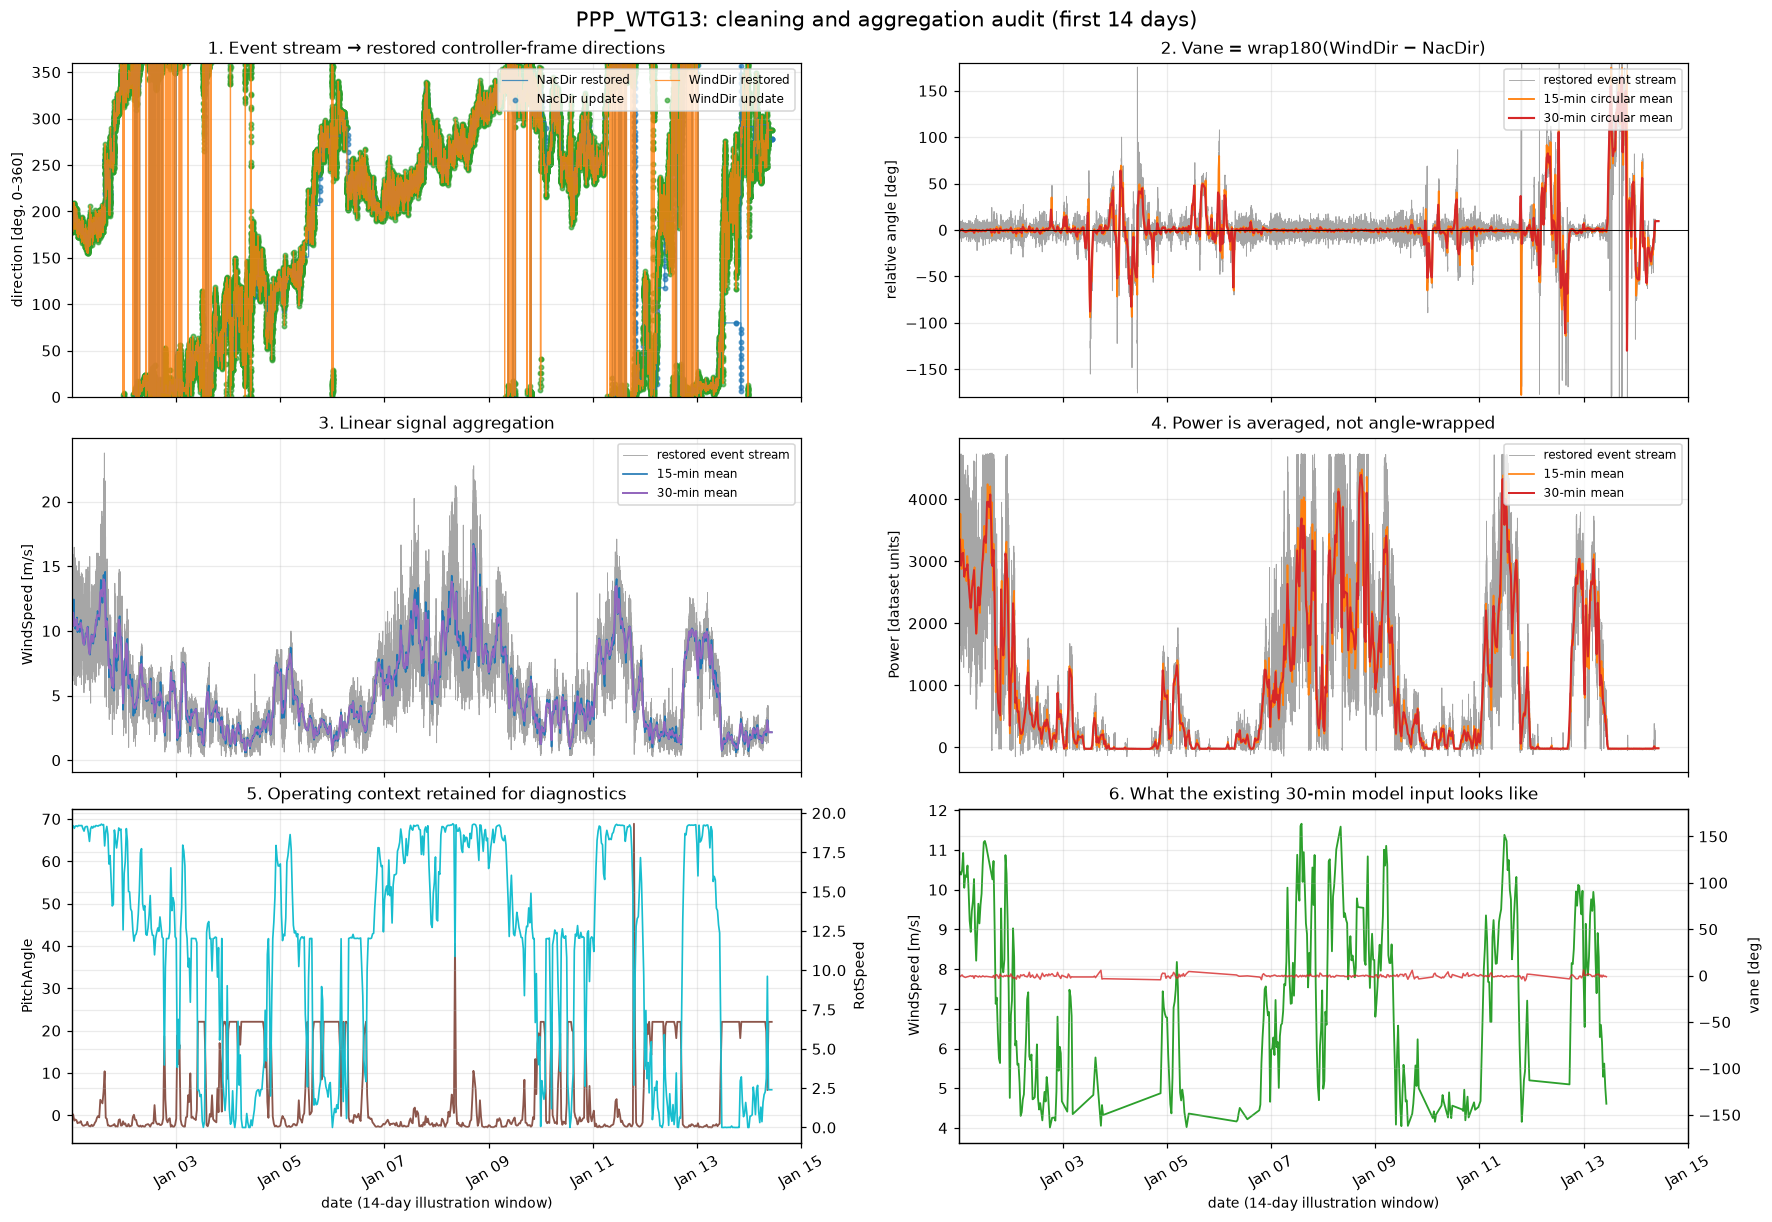

event_update_fraction = update rows / raw event rows; forward-filled rows are intentionally not counted as new updates.


,update_rows,event_update_fraction
channel,,
NacDir,373427,0.065
WindDir,3841323,0.666
WindSpeed,3908102,0.678
Power,3821942,0.663
PitchAngle,3600388,0.624
RotSpeed,3097314,0.537
GenSpeed,3830936,0.664


,rows
representation,
raw events,5766997
15-min circular/linear bins,68286
30-min circular/linear bins,34203
existing model bins,23356


In [4]:
# A compact side-by-side view: event updates, restored signals, and model-scale bins.
import matplotlib.dates as mdates
if not restored_events.empty:
    plot_start = restored_events['ts'].min()
    plot_end = plot_start + pd.Timedelta(days=14)
    event_window = restored_events[restored_events['ts'].between(plot_start, plot_end)]
    c15 = clean15.loc[clean15.index.to_series().between(plot_start, plot_end)]
    c30 = clean30.loc[clean30.index.to_series().between(plot_start, plot_end)]
    m30 = model30.loc[model30.index.to_series().between(plot_start, plot_end)] if not model30.empty else model30

    fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex='col', constrained_layout=True)
    ax = axes[0, 0]
    for col, color in [('NacDir', 'tab:blue'), ('WindDir', 'tab:green')]:
        if col in event_window:
            ax.plot(event_window['ts'], np.mod(event_window[col], 360), lw=0.8, alpha=0.8, label=f'{col} restored')
            upd = event_window[event_window[f'{col}_update']]
            ax.scatter(upd['ts'], np.mod(upd[col], 360), s=8, color=color, alpha=0.65, label=f'{col} update')
    ax.set_title('1. Event stream → restored controller-frame directions')
    ax.set_ylabel('direction [deg, 0–360]')
    ax.set_ylim(0, 360)
    ax.legend(ncol=2, loc='upper right')

    ax = axes[0, 1]
    ax.plot(event_window['ts'], event_window['vane'], color='0.65', lw=0.6, label='restored event stream')
    ax.plot(c15.index, c15['vane'], color='tab:orange', lw=1.2, label='15-min circular mean')
    ax.plot(c30.index, c30['vane'], color='tab:red', lw=1.4, label='30-min circular mean')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title('2. Vane = wrap180(WindDir − NacDir)')
    ax.set_ylabel('relative angle [deg]')
    ax.set_ylim(-180, 180)
    ax.legend(loc='upper right')

    ax = axes[1, 0]
    ax.plot(event_window['ts'], event_window['WindSpeed'], color='0.65', lw=0.6, label='restored event stream')
    ax.plot(c15.index, c15['WindSpeed'], color='tab:blue', lw=1.1, label='15-min mean')
    ax.plot(c30.index, c30['WindSpeed'], color='tab:purple', lw=1.3, label='30-min mean')
    ax.set_title('3. Linear signal aggregation')
    ax.set_ylabel('WindSpeed [m/s]')
    ax.legend(loc='upper right')

    ax = axes[1, 1]
    ax.plot(event_window['ts'], event_window['Power'], color='0.65', lw=0.6, label='restored event stream')
    ax.plot(c15.index, c15['Power'], color='tab:orange', lw=1.1, label='15-min mean')
    ax.plot(c30.index, c30['Power'], color='tab:red', lw=1.3, label='30-min mean')
    ax.set_title('4. Power is averaged, not angle-wrapped')
    ax.set_ylabel('Power [dataset units]')
    ax.legend(loc='upper right')

    ax = axes[2, 0]
    if 'PitchAngle' in c30:
        ax.plot(c30.index, c30['PitchAngle'], color='tab:brown', lw=1.2, label='30-min PitchAngle')
    if 'RotSpeed' in c30:
        ax2 = ax.twinx()
        ax2.plot(c30.index, c30['RotSpeed'], color='tab:cyan', lw=1.1, label='30-min RotSpeed')
        ax2.set_ylabel('RotSpeed')
    ax.set_title('5. Operating context retained for diagnostics')
    ax.set_ylabel('PitchAngle')

    ax = axes[2, 1]
    if not m30.empty and 'WindSpeed' in m30:
        ax.plot(m30.index, m30['WindSpeed'], color='tab:green', lw=1.2, label='model 30-min WindSpeed')
    if not m30.empty and 'vane' in m30:
        ax2 = ax.twinx()
        ax2.plot(m30.index, m30['vane'], color='tab:red', lw=1.0, alpha=0.8, label='model 30-min vane')
        ax2.set_ylabel('vane [deg]')
        ax2.set_ylim(-180, 180)
    ax.set_title('6. What the existing 30-min model input looks like')
    ax.set_ylabel('WindSpeed [m/s]')

    # Use a small number of day ticks instead of printing every SCADA timestamp.
    date_locator = mdates.DayLocator(interval=2)
    date_formatter = mdates.DateFormatter('%b %d')
    for ax in axes[-1, :]:
        ax.set_xlabel('date (14-day illustration window)')
        ax.set_xlim(plot_start, plot_end)
        ax.xaxis.set_major_locator(date_locator)
        ax.xaxis.set_major_formatter(date_formatter)
        ax.tick_params(axis='x', labelrotation=30)
    fig.suptitle(f'{CLEANING_TURBINE}: cleaning and aggregation audit (first 14 days)', fontsize=14)
    plt.show()

    update_summary = pd.DataFrame({
        'channel': [c for c in CLEANING_SIGNALS if f'{c}_update' in restored_events],
        'update_rows': [int(restored_events[f'{c}_update'].sum()) for c in CLEANING_SIGNALS if f'{c}_update' in restored_events],
        'event_update_fraction': [restored_events[f'{c}_update'].mean() for c in CLEANING_SIGNALS if f'{c}_update' in restored_events],
    }).reset_index(drop=True)
    print('event_update_fraction = update rows / raw event rows; forward-filled rows are intentionally not counted as new updates.')
    display(update_summary.round(3).set_index('channel'))
    display(pd.DataFrame({
        'representation': ['raw events', '15-min circular/linear bins', '30-min circular/linear bins', 'existing model bins'],
        'rows': [len(raw_events), len(clean15), len(clean30), len(model30)],
    }).set_index('representation'))
else:
    print('Run this cell after making data/train.parquet available under data/.')

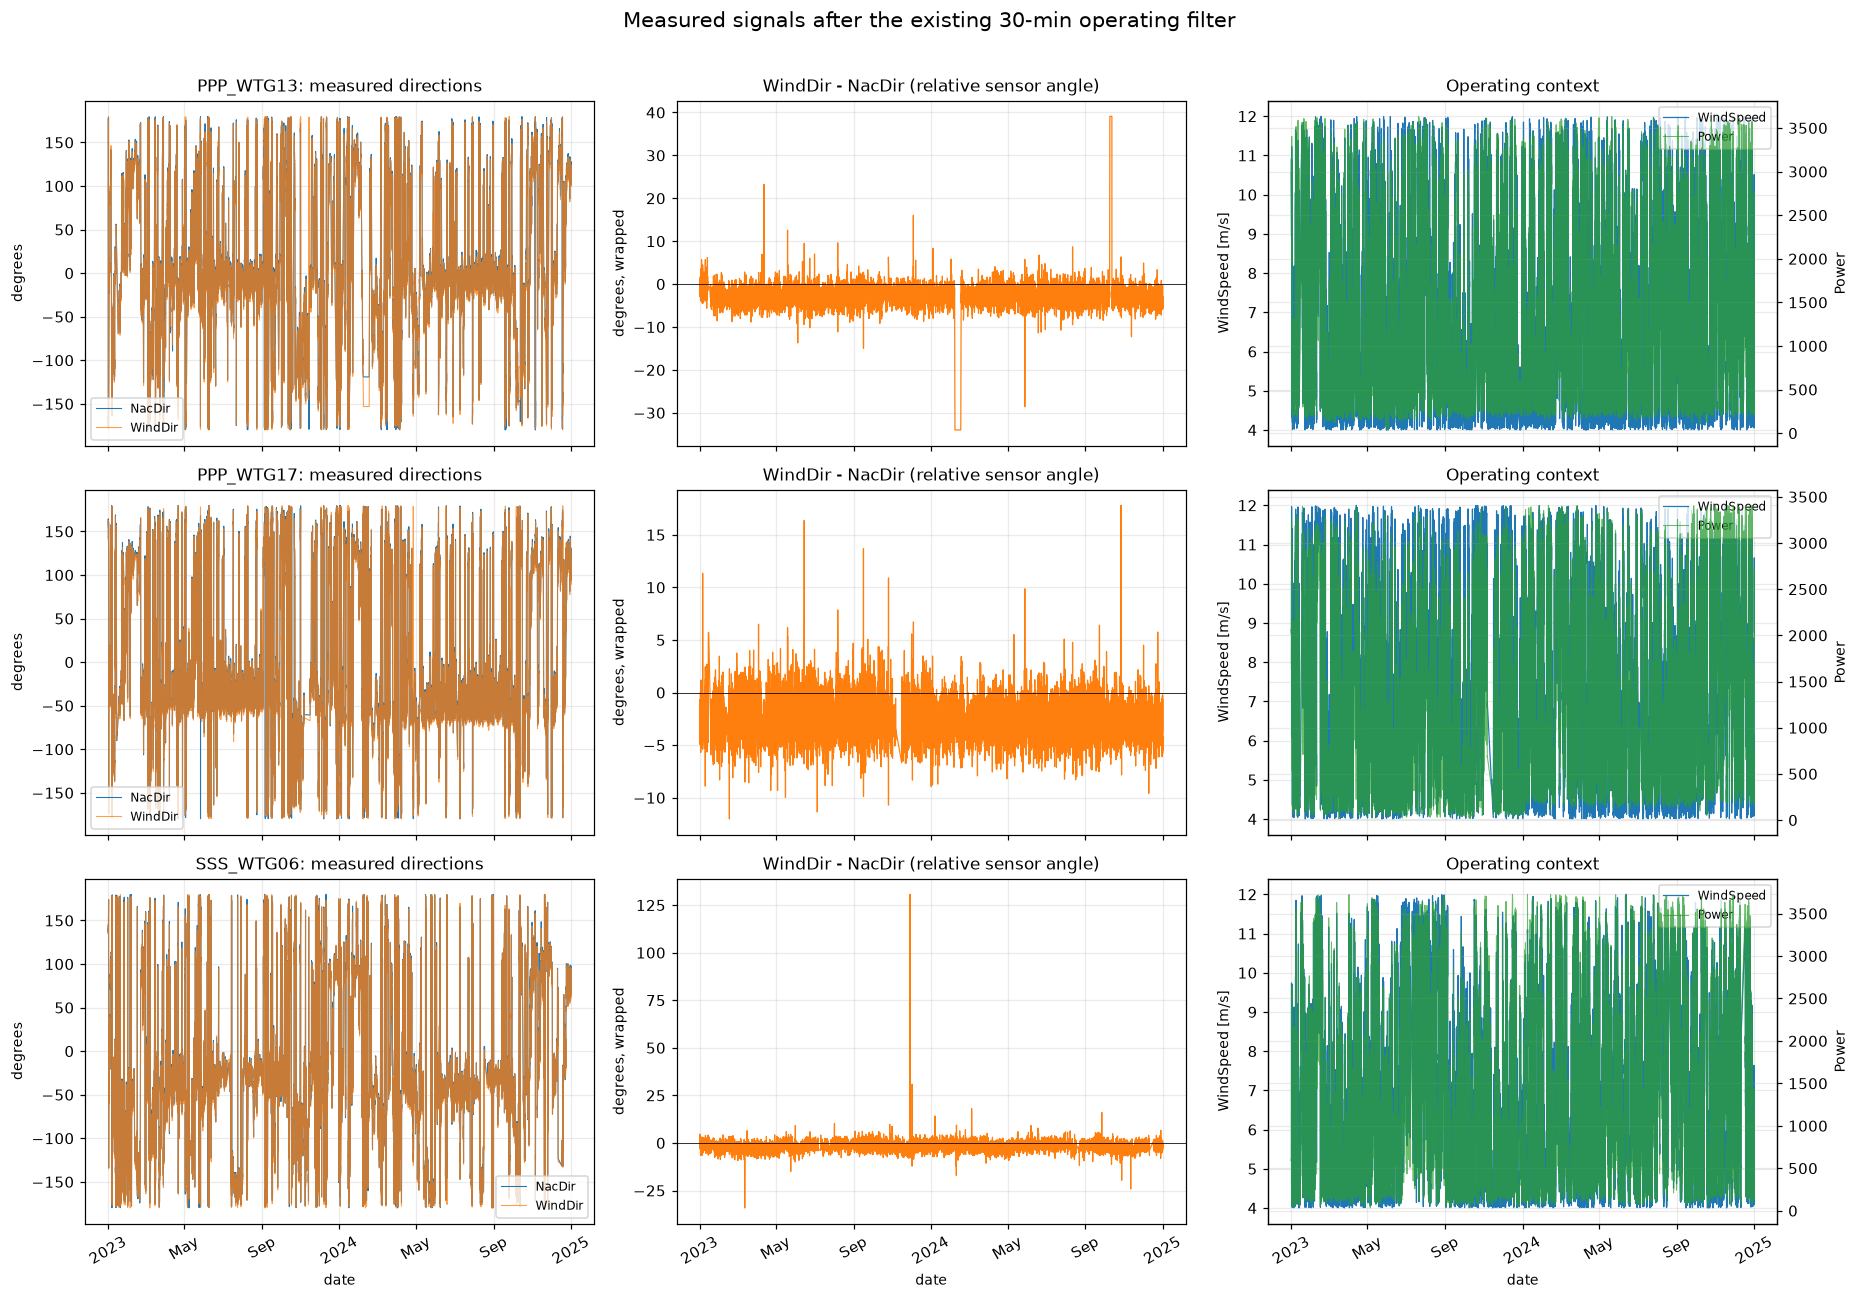

In [5]:
# Measured controller-frame angles and operating context.
fig, axes = plt.subplots(len(TARGETS), 3, figsize=(17, 4 * len(TARGETS)), squeeze=False, sharex='col')
for row, tid in enumerate(TARGETS):
    d = binned[tid].copy()
    axes[row, 0].plot(d.index, d['NacDir'], lw=0.7, label='NacDir')
    axes[row, 0].plot(d.index, d['WindDir'], lw=0.7, alpha=0.75, label='WindDir')
    axes[row, 0].set_title(f'{tid}: measured directions')
    axes[row, 0].set_ylabel('degrees')
    axes[row, 0].legend()
    axes[row, 1].plot(d.index, d['vane'], lw=0.8, color='tab:orange')
    axes[row, 1].axhline(0, color='k', lw=0.5)
    axes[row, 1].set_title('WindDir - NacDir (relative sensor angle)')
    axes[row, 1].set_ylabel('degrees, wrapped')
    ax = axes[row, 2]
    line_u, = ax.plot(d.index, d['WindSpeed'], color='tab:blue', lw=0.8, label='WindSpeed')
    ax2 = ax.twinx()
    line_p, = ax2.plot(d.index, d['Power'], color='tab:green', lw=0.7, alpha=0.7, label='Power')
    ax.set_title('Operating context'); ax.set_ylabel('WindSpeed [m/s]'); ax2.set_ylabel('Power')
    ax.legend([line_u, line_p], ['WindSpeed', 'Power'], loc='upper right')
for ax in axes[-1]: ax.set_xlabel('date')
date_locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
date_formatter = mdates.ConciseDateFormatter(date_locator)
for ax in axes[-1, :]:
    ax.xaxis.set_major_locator(date_locator)
    ax.xaxis.set_major_formatter(date_formatter)
    ax.tick_params(axis='x', labelrotation=30)
fig.suptitle('Measured signals after the existing 30-min operating filter', fontsize=14)
fig.align_ylabels(axes[:, :2])
fig.tight_layout(rect=[0, 0, 1, 0.97])

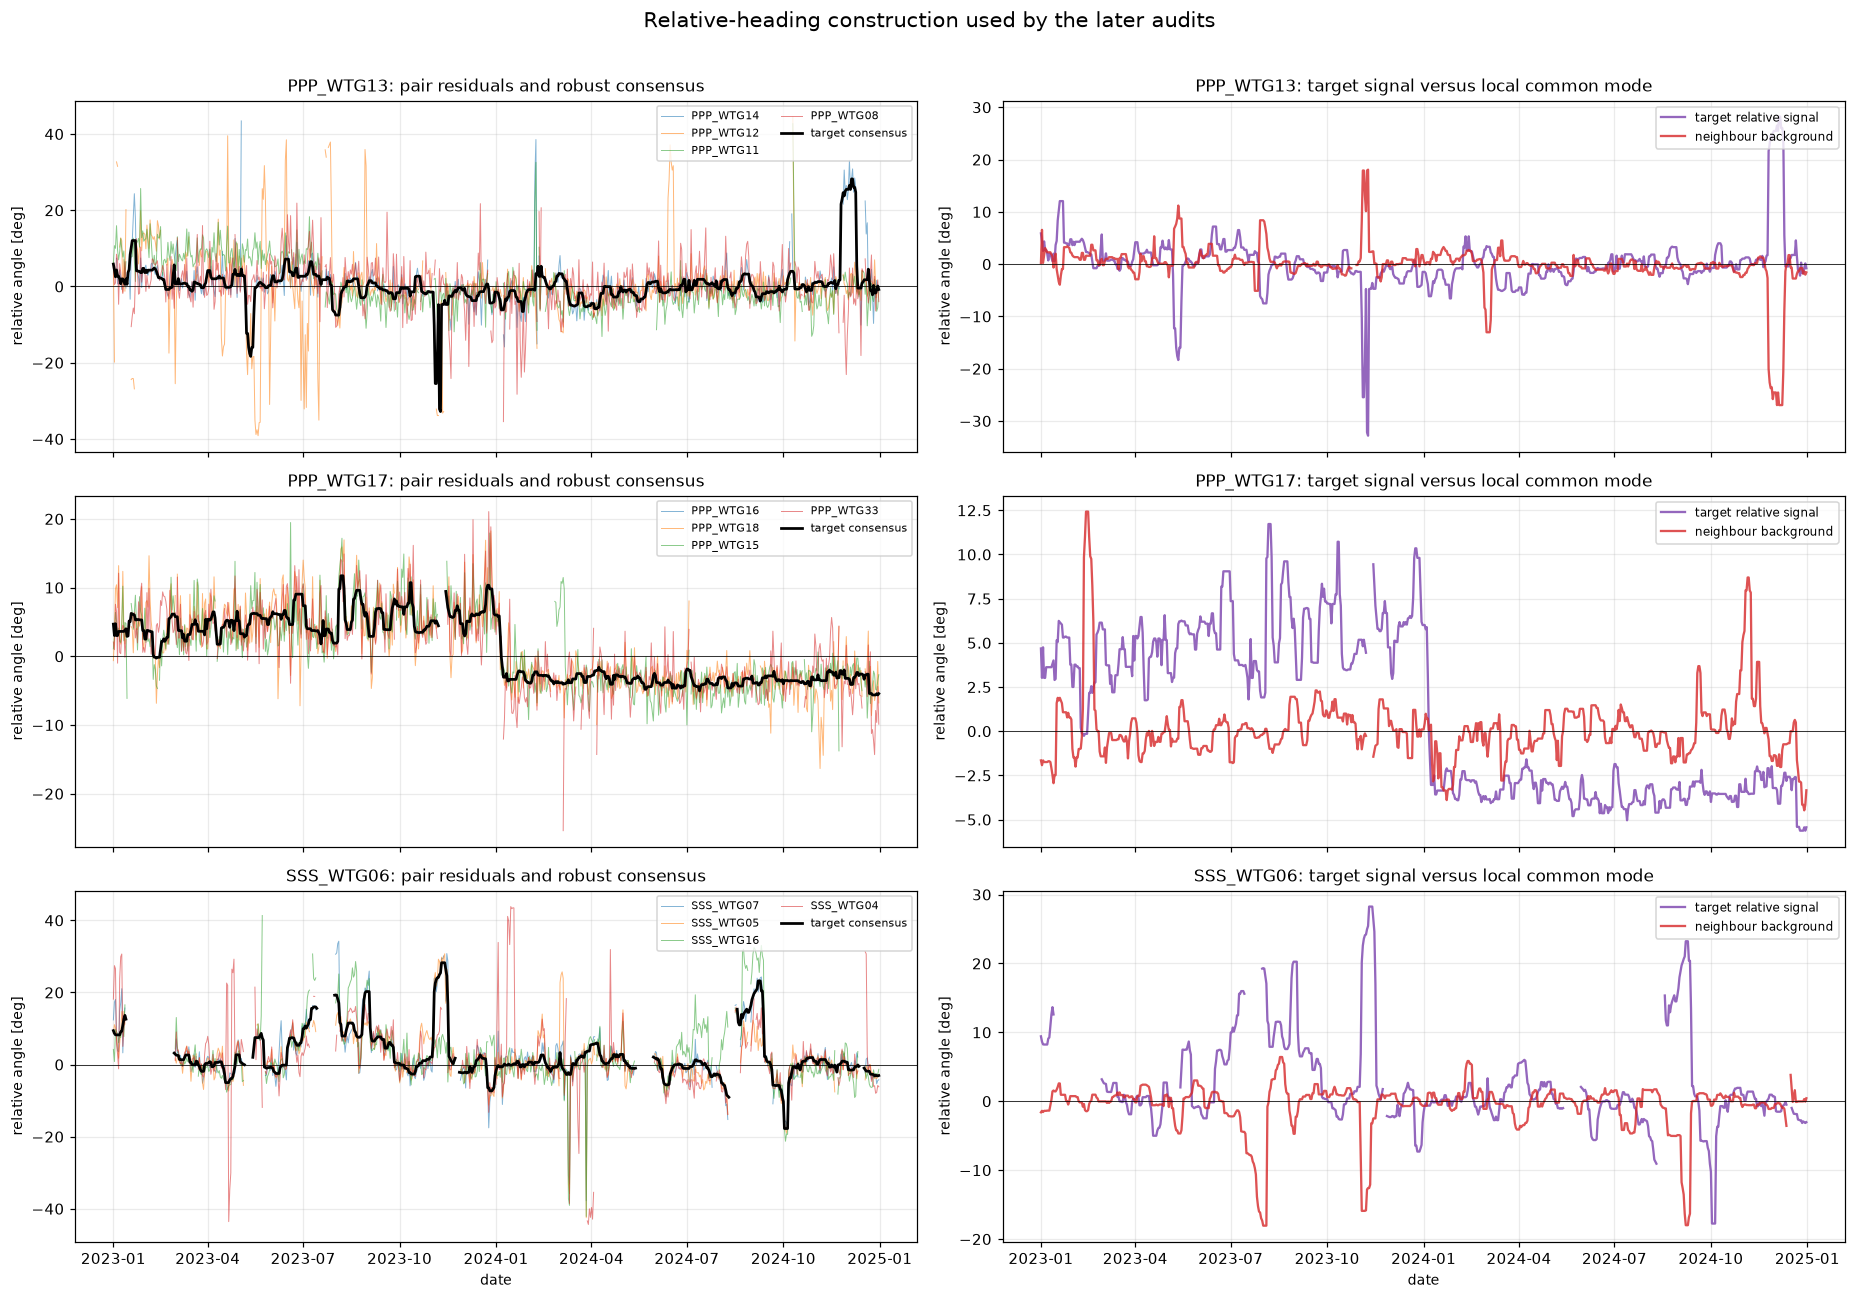

In [6]:
# Build the reusable relative-heading objects used by all later diagnostics.
# Keeping this cell explicit prevents downstream frozen-state plots from
# depending on an implicitly executed or hidden computation.
bundles = {}
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(17, 4 * len(TARGETS)), squeeze=False, sharex='col')
for row, tid in enumerate(TARGETS):
    daily, diag, pair_daily = fleet_relative_series(tid, binned, layout, fleet_cfg, rel_cfg)
    bundles[tid] = (daily, diag, pair_daily)
    ax = axes[row, 0]
    if not pair_daily.empty:
        for col in pair_daily.columns:
            ax.plot(pair_daily.index, pair_daily[col], lw=0.65, alpha=0.55, label=str(col))
    if not daily.empty and 'relative_heading_smooth' in daily:
        ax.plot(daily.index, daily['relative_heading_smooth'], color='black', lw=1.8, label='target consensus')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('relative angle [deg]')
    ax.set_title(f'{tid}: pair residuals and robust consensus')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax = axes[row, 1]
    if not daily.empty:
        if 'relative_heading_smooth' in daily:
            ax.plot(daily.index, daily['relative_heading_smooth'], color='tab:purple', label='target relative signal')
        if 'background_residual_smooth' in daily:
            ax.plot(daily.index, daily['background_residual_smooth'], color='tab:red', alpha=0.8, label='neighbour background')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('relative angle [deg]')
    ax.set_title(f'{tid}: target signal versus local common mode')
    ax.legend(fontsize=8, loc='upper right')
for ax in axes[-1, :]: ax.set_xlabel('date')
fig.suptitle('Relative-heading construction used by the later audits', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])

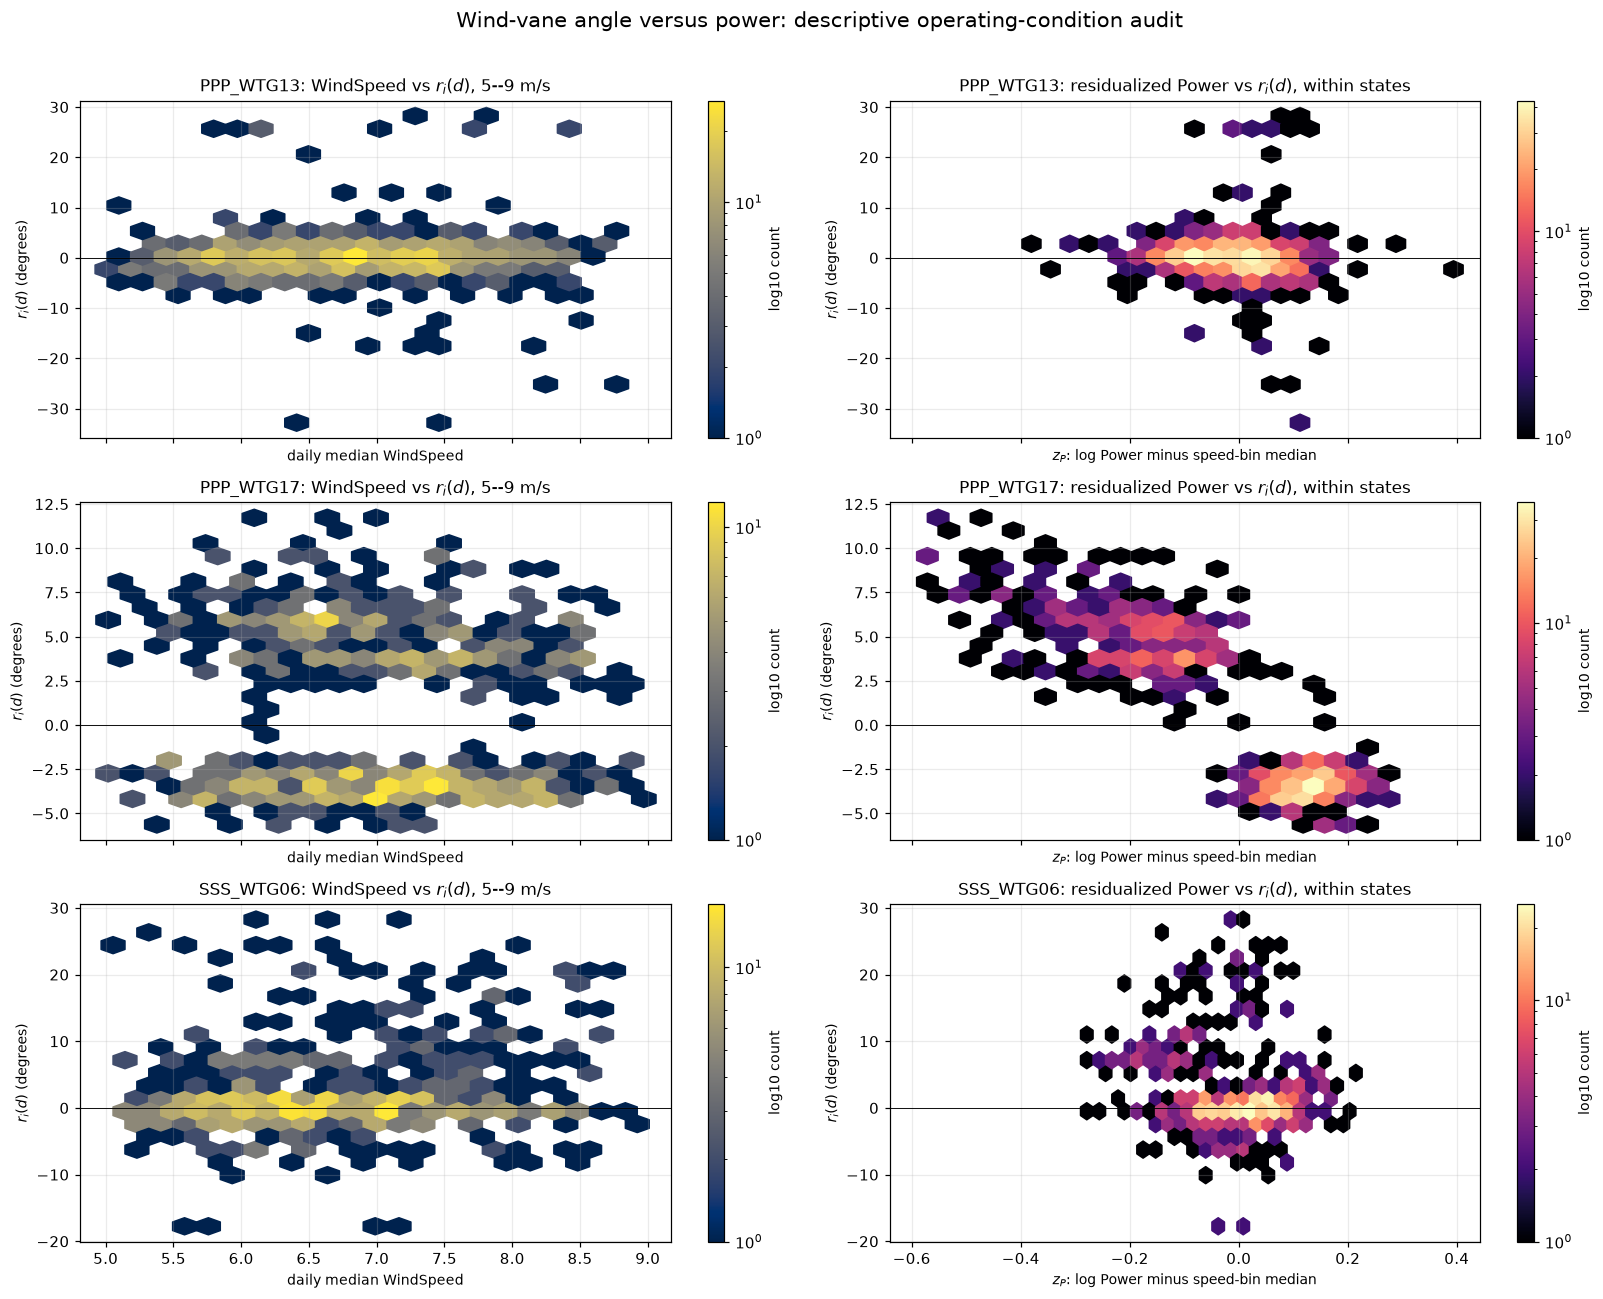

Within-state residual-Power diagnostics:


,turbine,state,n_days,r_p05,r_p95,spearman_zpower_vs_r
0,PPP_WTG13,0,43,1.342,12.058,0.061
1,PPP_WTG13,1,154,-3.805,5.324,-0.014
2,PPP_WTG13,2,216,-6.588,2.700,-0.043
3,PPP_WTG13,3,290,-4.992,4.294,-0.086
4,PPP_WTG17,0,160,2.171,6.464,-0.279
5,PPP_WTG17,1,89,2.228,9.827,-0.519
6,PPP_WTG17,2,20,6.968,10.721,-0.293
7,PPP_WTG17,3,72,3.285,9.809,-0.413
8,PPP_WTG17,4,340,-4.632,-2.247,0.149
9,SSS_WTG06,0,80,-4.305,9.256,-0.133


Large relative-signal events versus pair quality:


r         pair_spread_deg        n_usable_pairs       
                  count  median           count median          count median
turbine   large_r                                                           
PPP_WTG13 False     698  -0.115             684  1.683            698    4.0
          True       33  12.058              32  3.868             33    4.0
PPP_WTG17 False     718  -1.617             703  0.742            718    3.0
          True        7  10.721               7  1.251              7    3.0
SSS_WTG06 False     549   0.225             528  0.828            549    4.0
          True       84  15.603              74  3.866             84    4.0

In [7]:
from yaw_relative_state import label_free_boundaries, clusters_from_boundaries

state_power_rows = []
state_quality_rows = []
frozen_state_tables = {}
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(15, 4.0 * len(TARGETS)), squeeze=False, sharex='col')

for row, tid in enumerate(TARGETS):
    daily, diag, pair_daily = bundles.get(tid, (pd.DataFrame(), pd.DataFrame(), pd.DataFrame()))
    if daily.empty or pair_daily.empty:
        continue

    # Detect once with the existing configuration, then treat these dates as frozen.
    weights = diag.reindex(pair_daily.columns)['reliability_weight'].to_numpy(dtype=float)
    boundaries = label_free_boundaries(daily, pair_daily, weights, rel_cfg)
    state_id = clusters_from_boundaries(daily.index, boundaries)
    frozen_state_tables[tid] = boundaries.copy()

    d = binned[tid][['WindSpeed', 'Power', 'PitchAngle']].apply(pd.to_numeric, errors='coerce')
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d['WindSpeed'].between(5.0, 9.0) & (d['Power'] > 0)]
    if d.empty:
        continue
    low_speed = d['WindSpeed'].between(5.0, 9.0)
    pitch_limit = d.loc[low_speed, 'PitchAngle'].quantile(0.90) + 0.5
    d = d[d['PitchAngle'] <= pitch_limit].copy()
    d['speed_bin'] = np.floor(d['WindSpeed'] * 2.0) / 2.0
    d['log_power'] = np.log(d['Power'])
    d['z_power'] = d['log_power'] - d.groupby('speed_bin', observed=True)['log_power'].transform('median')
    d['date'] = pd.to_datetime(d.index).normalize()
    power_daily = d.groupby('date')[['WindSpeed', 'z_power']].median()
    joined = power_daily.join(daily[['relative_heading_smooth']].rename(columns={'relative_heading_smooth': 'r'}), how='inner')
    joined['state'] = state_id.reindex(joined.index).to_numpy()
    joined = joined.replace([np.inf, -np.inf], np.nan).dropna(subset=['WindSpeed', 'z_power', 'r', 'state'])

    ax = axes[row, 0]
    hb = ax.hexbin(joined['WindSpeed'], joined['r'], gridsize=22, mincnt=1, bins='log', cmap='cividis')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(f'{tid}: WindSpeed vs $r_i(d)$, 5--9 m/s')
    ax.set_xlabel('daily median WindSpeed')
    ax.set_ylabel('$r_i(d)$ (degrees)')
    fig.colorbar(hb, ax=ax, label='log10 count')

    ax = axes[row, 1]
    hb = ax.hexbin(joined['z_power'], joined['r'], gridsize=22, mincnt=1, bins='log', cmap='magma')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(f'{tid}: residualized Power vs $r_i(d)$, within states')
    ax.set_xlabel('$z_P$: log Power minus speed-bin median')
    ax.set_ylabel('$r_i(d)$ (degrees)')
    fig.colorbar(hb, ax=ax, label='log10 count')

    for state, part in joined.groupby('state', observed=True):
        if len(part) < 8:
            continue
        state_power_rows.append({
            'turbine': tid,
            'state': int(state),
            'n_days': len(part),
            'r_p05': part['r'].quantile(0.05),
            'r_p95': part['r'].quantile(0.95),
            'spearman_zpower_vs_r': part['z_power'].corr(part['r'], method='spearman'),
        })

    pair_values = pair_daily.reindex(daily.index).to_numpy(dtype=float)
    has_pair = np.isfinite(pair_values).any(axis=1)
    pair_median = np.full(len(pair_values), np.nan)
    pair_median[has_pair] = np.nanmedian(pair_values[has_pair], axis=1)
    pair_dev = np.abs(pair_values - pair_median[:, None])
    pair_spread = np.full(len(pair_values), np.nan)
    pair_spread[has_pair] = np.nanmedian(pair_dev[has_pair], axis=1)
    quality = pd.DataFrame({
        'r': daily['relative_heading_smooth'].to_numpy(dtype=float),
        'pair_spread_deg': pair_spread,
        'n_usable_pairs': np.isfinite(pair_values).sum(axis=1),
    }, index=daily.index).dropna(subset=['r'])
    quality['large_r'] = quality['r'].abs() > 10.0
    quality['turbine'] = tid
    state_quality_rows.append(quality.reset_index(names='date'))

fig.suptitle('Wind-vane angle versus power: descriptive operating-condition audit', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print('Within-state residual-Power diagnostics:')
display(pd.DataFrame(state_power_rows).round(3))
print('Large relative-signal events versus pair quality:')
quality_table = pd.concat(state_quality_rows, ignore_index=True) if state_quality_rows else pd.DataFrame()
if not quality_table.empty:
    display(quality_table.groupby(['turbine', 'large_r'], observed=True)[['r', 'pair_spread_deg', 'n_usable_pairs']].agg(['count', 'median']).round(3))

## Wind Vane Angle versus Power

Here `vane = wrap180(WindDir - NacDir)` is the controller-frame vane reading used by the existing preprocessing. The speed-stratified curves show whether any apparent Power--vane pattern remains after separating WindSpeed bands. This is a physical diagnostic only, not a new yaw estimator.

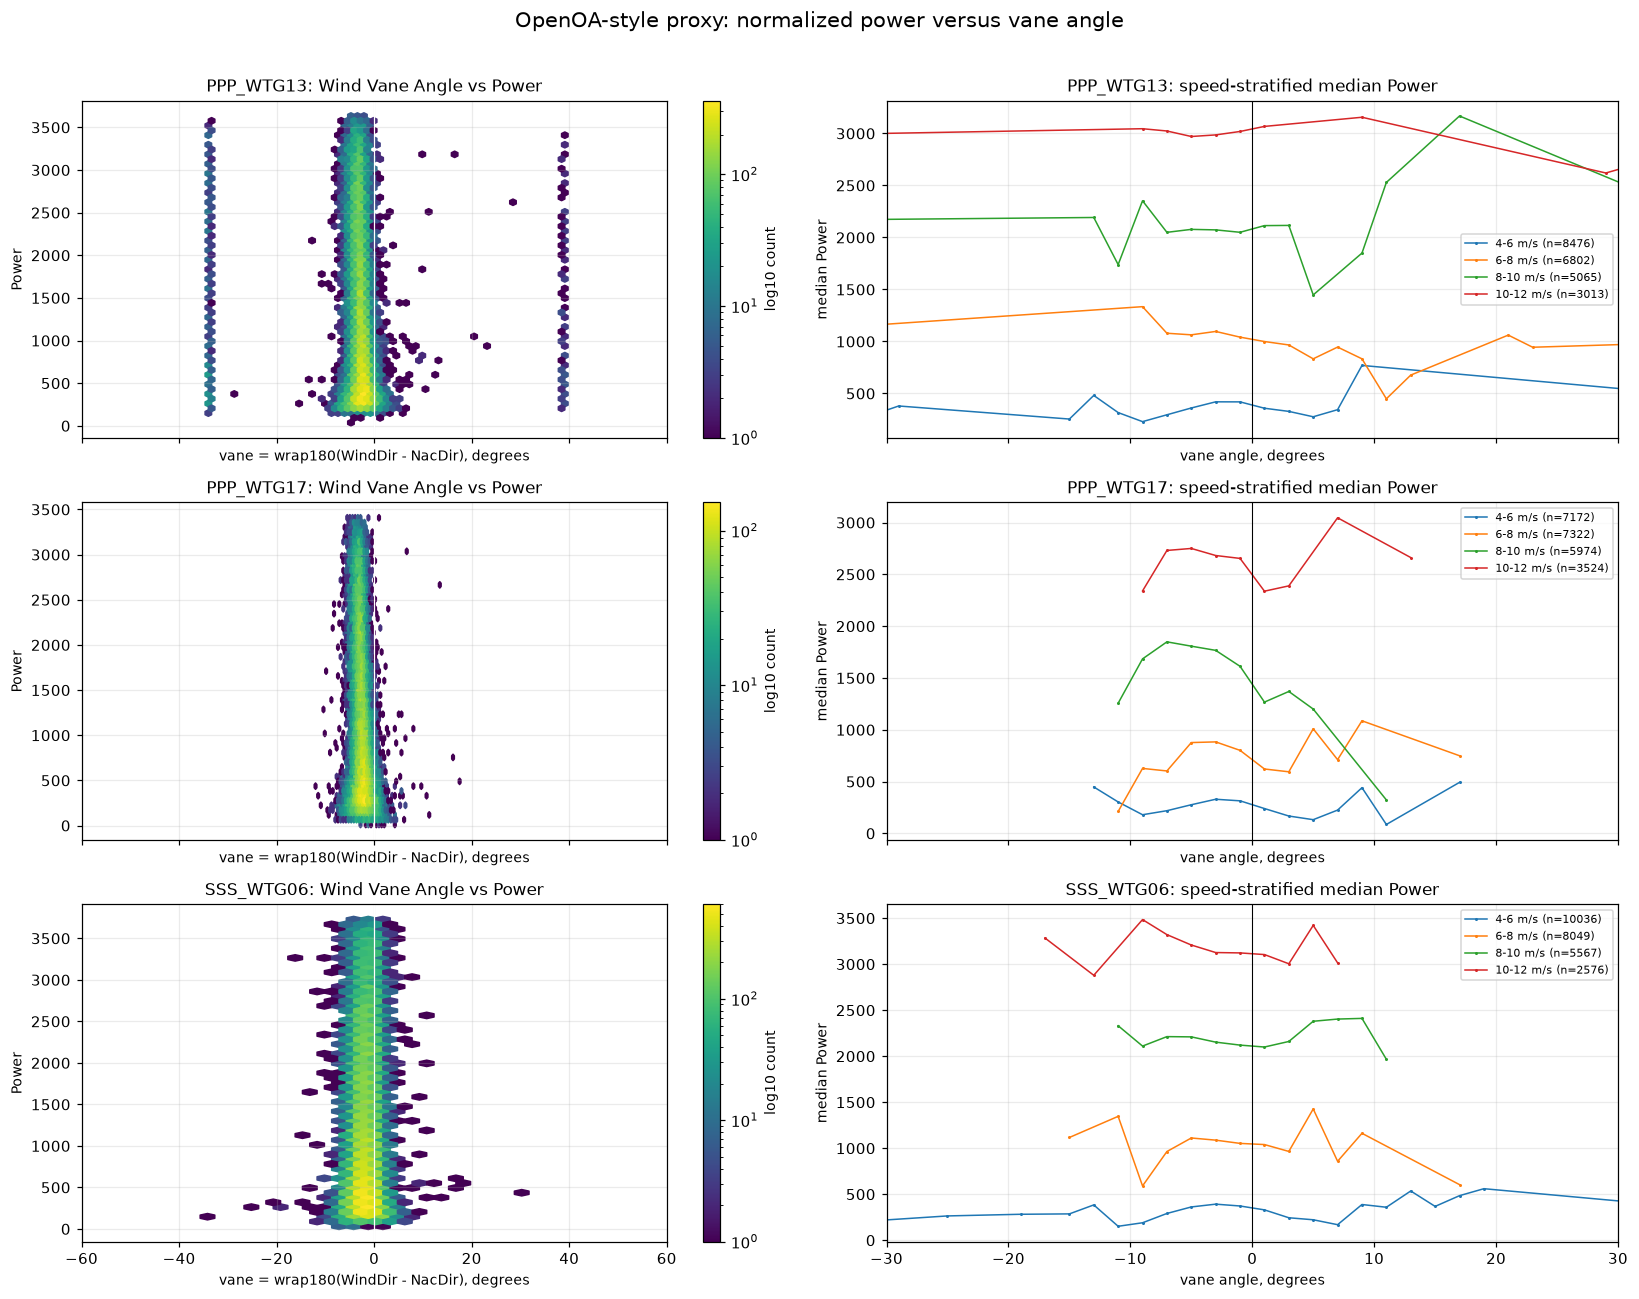

,turbine,n_30min_bins,vane_p05,vane_median,vane_p95,power_median
0,PPP_WTG13,23356,-5.612,-2.707,-0.115,1047.616
1,PPP_WTG17,23992,-4.830,-2.557,0.018,964.145
2,SSS_WTG06,26228,-5.043,-1.686,1.429,960.749


In [8]:
# Wind Vane Angle versus Power, stratified by WindSpeed.
vane_power_rows = []
speed_bands = [(4, 6), (6, 8), (8, 10), (10, 12)]
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(15, 4.0 * len(TARGETS)), squeeze=False, sharex='col')
for row, tid in enumerate(TARGETS):
    d = binned[tid][['vane', 'Power', 'WindSpeed']].apply(pd.to_numeric, errors='coerce')
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d['Power'] > 0]
    if d.empty:
        continue

    ax = axes[row, 0]
    hb = ax.hexbin(d['vane'], d['Power'], gridsize=(55, 32), mincnt=1, bins='log', cmap='viridis')
    ax.axvline(0, color='white', lw=0.8)
    ax.set_xlim(-60, 60)
    ax.set_title(f'{tid}: Wind Vane Angle vs Power')
    ax.set_xlabel('vane = wrap180(WindDir - NacDir), degrees')
    ax.set_ylabel('Power')
    fig.colorbar(hb, ax=ax, label='log10 count')

    ax = axes[row, 1]
    d['vane_bin'] = np.floor((d['vane'] + 60.0) / 2.0) * 2.0 - 59.0
    for lo, hi in speed_bands:
        part = d[d['WindSpeed'].between(lo, hi, inclusive='left')]
        curve = part.groupby('vane_bin', observed=True)['Power'].median()
        if not curve.empty:
            ax.plot(curve.index, curve.values, marker='.', ms=2, lw=1.0, label=f'{lo}-{hi} m/s (n={len(part)})')
    ax.axvline(0, color='k', lw=0.7)
    ax.set_xlim(-30, 30)
    ax.set_title(f'{tid}: speed-stratified median Power')
    ax.set_xlabel('vane angle, degrees')
    ax.set_ylabel('median Power')
    ax.legend(fontsize=7)

    vane_power_rows.append({
        'turbine': tid,
        'n_30min_bins': len(d),
        'vane_p05': d['vane'].quantile(0.05),
        'vane_median': d['vane'].median(),
        'vane_p95': d['vane'].quantile(0.95),
        'power_median': d['Power'].median(),
    })
for ax in axes[-1]:
    ax.set_xlabel(ax.get_xlabel())
fig.suptitle('OpenOA-style proxy: normalized power versus vane angle', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
display(pd.DataFrame(vane_power_rows).round(3))

## Frozen-boundary heading-quality state-level audit

The existing accepted boundaries are detected once and then held fixed. Only the state-level aggregation changes: the quality mask uses pair residual spread and the number of available pairs. Power, PitchAngle, and WindSpeed are not used in this mask.

In [9]:
from fleet_context import circular_median_deg
from yaw_relative_state import label_free_boundaries, clusters_from_boundaries

PAIR_SPREAD_LIMIT_DEG = 2.5
MIN_USABLE_PAIRS = 2
qc_state_rows = []
qc_boundary_rows = []
qc_daily_tables = {}

for tid in TARGETS:
    daily, diag, pair_daily = bundles.get(tid, (pd.DataFrame(), pd.DataFrame(), pd.DataFrame()))
    if daily.empty or pair_daily.empty:
        continue
    if tid not in frozen_state_tables or frozen_state_tables[tid].empty:
        weights = diag.reindex(pair_daily.columns)['reliability_weight'].to_numpy(dtype=float)
        frozen_state_tables[tid] = label_free_boundaries(daily, pair_daily, weights, rel_cfg)
    boundaries = frozen_state_tables[tid]
    state_id = clusters_from_boundaries(daily.index, boundaries)

    values = pair_daily.reindex(daily.index).to_numpy(dtype=float)
    has_pair = np.isfinite(values).any(axis=1)
    pair_median = np.full(len(values), np.nan)
    pair_median[has_pair] = np.nanmedian(values[has_pair], axis=1)
    circular_deviation = np.abs(wrap_180(values - pair_median[:, None]))
    pair_spread = np.full(len(values), np.nan)
    pair_p90 = np.full(len(values), np.nan)
    pair_spread[has_pair] = np.nanmedian(circular_deviation[has_pair], axis=1)
    pair_p90[has_pair] = np.nanpercentile(circular_deviation[has_pair], 90, axis=1)
    n_pairs = np.isfinite(values).sum(axis=1)
    quality = pd.DataFrame({
        'state': state_id.to_numpy(dtype=int),
        'r': daily['relative_heading_smooth'].to_numpy(dtype=float),
        'pair_spread_deg': pair_spread,
        'pair_p90_deg': pair_p90,
        'n_usable_pairs': n_pairs,
    }, index=daily.index)
    quality['quality_ok'] = (
        quality['pair_spread_deg'] <= PAIR_SPREAD_LIMIT_DEG
    ) & (quality['n_usable_pairs'] >= MIN_USABLE_PAIRS)
    qc_daily_tables[tid] = quality

    state_levels = {}
    for state, part in quality.groupby('state', observed=True):
        all_values = part['r'].dropna()
        qc_values = part.loc[part['quality_ok'], 'r'].dropna()
        state_levels[int(state)] = {
            'all': circular_median_deg(all_values),
            'qc': circular_median_deg(qc_values),
        }
        qc_state_rows.append({
            'turbine': tid,
            'state': int(state),
            'n_all_days': len(all_values),
            'n_qc_days': len(qc_values),
            'qc_fraction': len(qc_values) / max(len(all_values), 1),
            'level_all_deg': state_levels[int(state)]['all'],
            'level_qc_deg': state_levels[int(state)]['qc'],
        })

    accepted_dates = pd.DatetimeIndex(boundaries.index[boundaries['accepted'].fillna(False)])
    for date in accepted_dates:
        left_state = state_id.get(date - pd.Timedelta(days=1), np.nan)
        right_state = state_id.get(date, np.nan)
        if not np.isfinite(left_state) or not np.isfinite(right_state) or left_state == right_state:
            continue
        left = state_levels.get(int(left_state), {})
        right = state_levels.get(int(right_state), {})
        qc_boundary_rows.append({
            'turbine': tid,
            'boundary': date,
            'jump_all_deg': wrap_180(right.get('all', np.nan) - left.get('all', np.nan)),
            'jump_qc_deg': wrap_180(right.get('qc', np.nan) - left.get('qc', np.nan)),
            'qc_days_left': int((quality['state'] == left_state).sum()),
            'qc_days_right': int((quality['state'] == right_state).sum()),
        })

print(f'Heading-only mask: pair spread <= {PAIR_SPREAD_LIMIT_DEG:.1f} deg and at least {MIN_USABLE_PAIRS} usable pairs')
display(pd.DataFrame(qc_state_rows).round(3))
print('Frozen-boundary state jumps: all days versus heading-QC days')
display(pd.DataFrame(qc_boundary_rows).round(3))

Heading-only mask: pair spread <= 2.5 deg and at least 2 usable pairs


,turbine,state,n_all_days,n_qc_days,qc_fraction,level_all_deg,level_qc_deg
0,PPP_WTG13,0,49,15,0.306,3.970,4.111
1,PPP_WTG13,1,158,71,0.449,1.707,1.826
2,PPP_WTG13,2,227,157,0.692,-1.292,-1.043
3,PPP_WTG13,3,297,235,0.791,-0.596,-0.819
4,PPP_WTG17,0,175,159,0.909,4.641,4.682
5,PPP_WTG17,1,91,84,0.923,4.150,4.010
6,PPP_WTG17,2,21,18,0.857,7.340,7.340
7,PPP_WTG17,3,78,71,0.910,5.780,5.663
8,PPP_WTG17,4,360,317,0.881,-3.429,-3.429
9,SSS_WTG06,0,81,69,0.852,0.636,0.587


Frozen-boundary state jumps: all days versus heading-QC days


C:\Users\HJL\AppData\Local\Temp\ipykernel_27016\3609782061.py:80: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(pd.DataFrame(qc_boundary_rows).round(3))


,turbine,boundary,jump_all_deg,jump_qc_deg,qc_days_left,qc_days_right
0,PPP_WTG13,2023-02-19,-2.262,-2.285,49,158
1,PPP_WTG13,2023-07-27,-3.000,-2.868,158,227
2,PPP_WTG13,2024-03-10,0.696,0.224,227,297
3,PPP_WTG17,2023-06-25,-0.491,-0.672,175,91
4,PPP_WTG17,2023-09-24,3.190,3.330,91,21
5,PPP_WTG17,2023-10-15,-1.560,-1.678,21,84
6,PPP_WTG17,2024-01-07,-9.210,-9.092,84,360
7,SSS_WTG06,2023-05-07,6.793,6.904,126,21
8,SSS_WTG06,2023-05-28,0.148,-0.746,21,119
9,SSS_WTG06,2023-09-24,-7.424,-6.879,119,385


## OpenOA-style Wind Vane Angle versus normalized Power

OpenOA uses a power-coefficient proxy to reduce the dominant WindSpeed effect: $C_{P,\mathrm{proxy}}=Power/WindSpeed^3$. This cell restricts the descriptive plot to the below-rated comparison range and $|vane|\le25^\circ$; it does not fit a cosine curve or replace the RRS model.

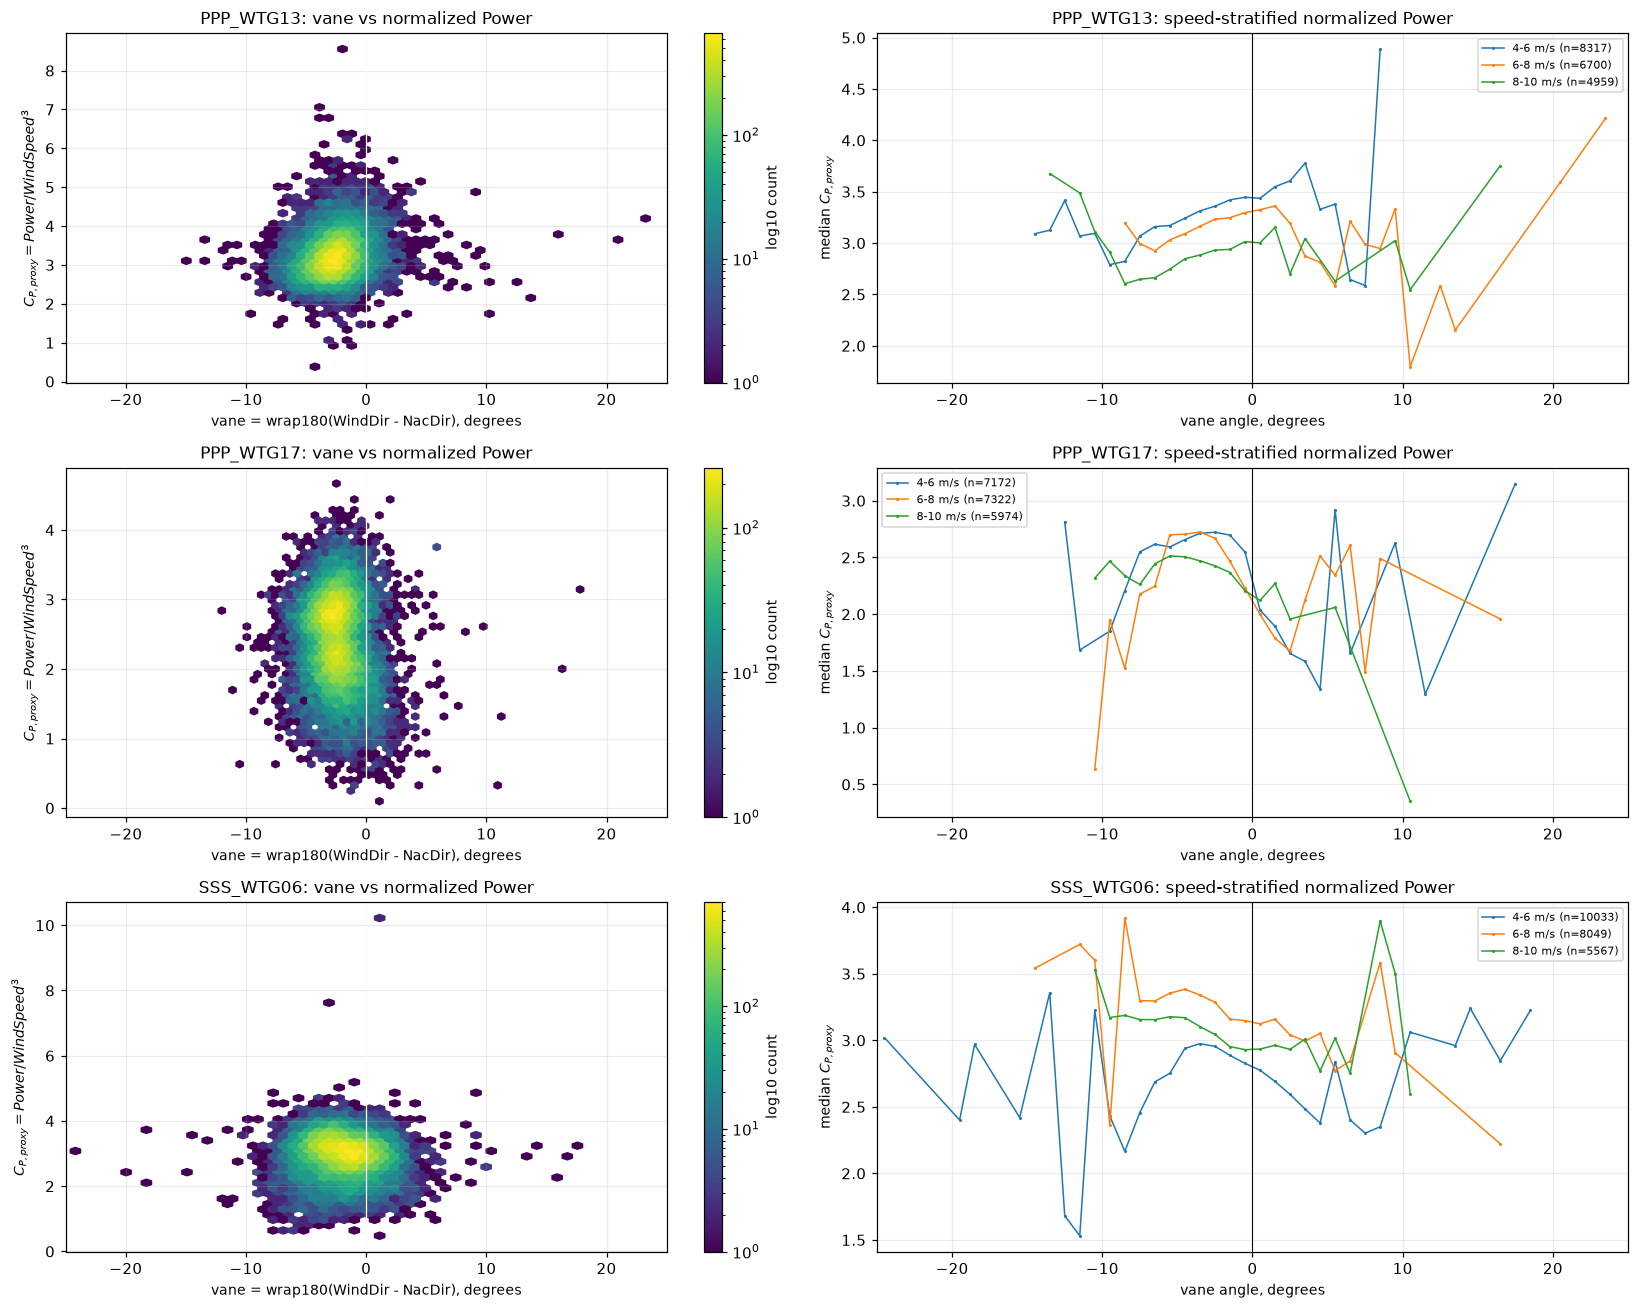

,turbine,n_30min_bins,vane_p05,vane_p95,cp_proxy_median,cp_proxy_p05,cp_proxy_p95
0,PPP_WTG13,19976,-5.184275,-0.067632,3.168762,2.566022,4.015740
1,PPP_WTG17,20469,-4.788592,0.183985,2.518449,1.454274,3.291984
2,SSS_WTG06,23649,-5.099277,1.428541,3.041013,2.084401,3.707408


In [10]:
# OpenOA-style normalized Power (power coefficient proxy) versus vane angle.
normalized_vane_rows = []
speed_bands = [(4, 6), (6, 8), (8, 10)]
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(15, 4.0 * len(TARGETS)), squeeze=False)
for row, tid in enumerate(TARGETS):
    d = binned[tid][['vane', 'Power', 'WindSpeed']].apply(pd.to_numeric, errors='coerce')
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    d = d[(d['Power'] > 0) & d['WindSpeed'].between(4.0, 10.0) & (d['vane'].abs() <= 25.0)].copy()
    if d.empty:
        continue
    d['cp_proxy'] = d['Power'] / np.maximum(d['WindSpeed'], 0.1) ** 3
    d['vane_bin'] = np.floor((d['vane'] + 25.0) / 1.0) * 1.0 - 24.5

    ax = axes[row, 0]
    hb = ax.hexbin(d['vane'], d['cp_proxy'], gridsize=(50, 30), mincnt=1, bins='log', cmap='viridis')
    ax.axvline(0, color='white', lw=0.8)
    ax.set_xlim(-25, 25)
    ax.set_title(f'{tid}: vane vs normalized Power')
    ax.set_xlabel('vane = wrap180(WindDir - NacDir), degrees')
    ax.set_ylabel('$C_{P,proxy}=Power/WindSpeed^3$')
    fig.colorbar(hb, ax=ax, label='log10 count')

    ax = axes[row, 1]
    for lo, hi in speed_bands:
        part = d[d['WindSpeed'].between(lo, hi, inclusive='left')]
        curve = part.groupby('vane_bin', observed=True)['cp_proxy'].median()
        if not curve.empty:
            ax.plot(curve.index, curve.values, marker='.', ms=2, lw=1.0, label=f'{lo}-{hi} m/s (n={len(part)})')
    ax.axvline(0, color='k', lw=0.7)
    ax.set_xlim(-25, 25)
    ax.set_title(f'{tid}: speed-stratified normalized Power')
    ax.set_xlabel('vane angle, degrees')
    ax.set_ylabel('median $C_{P,proxy}$')
    ax.legend(fontsize=7)

    normalized_vane_rows.append({
        'turbine': tid,
        'n_30min_bins': len(d),
        'vane_p05': d['vane'].quantile(0.05),
        'vane_p95': d['vane'].quantile(0.95),
        'cp_proxy_median': d['cp_proxy'].median(),
        'cp_proxy_p05': d['cp_proxy'].quantile(0.05),
        'cp_proxy_p95': d['cp_proxy'].quantile(0.95),
    })
plt.tight_layout()
plt.show()
display(pd.DataFrame(normalized_vane_rows).round(6))

## Geometry-based wake-direction audit

This is an independent diagnostic inspired by OpenOA wake-loss calibration. For a candidate upstream/downstream pair, it compares the measured wind-from direction at the upstream turbine with the geometric direction from downstream to upstream, then examines the condition-normalized power ratio $C_{P,down}/C_{P,up}$. It does not modify RRS or create a yaw prediction. The result is meaningful as an absolute direction-frame audit only if `WindDir` is an independent absolute wind-direction signal; if it is controller-derived from `NacDir + vane`, interpret it as a consistency check rather than a northing calibration.

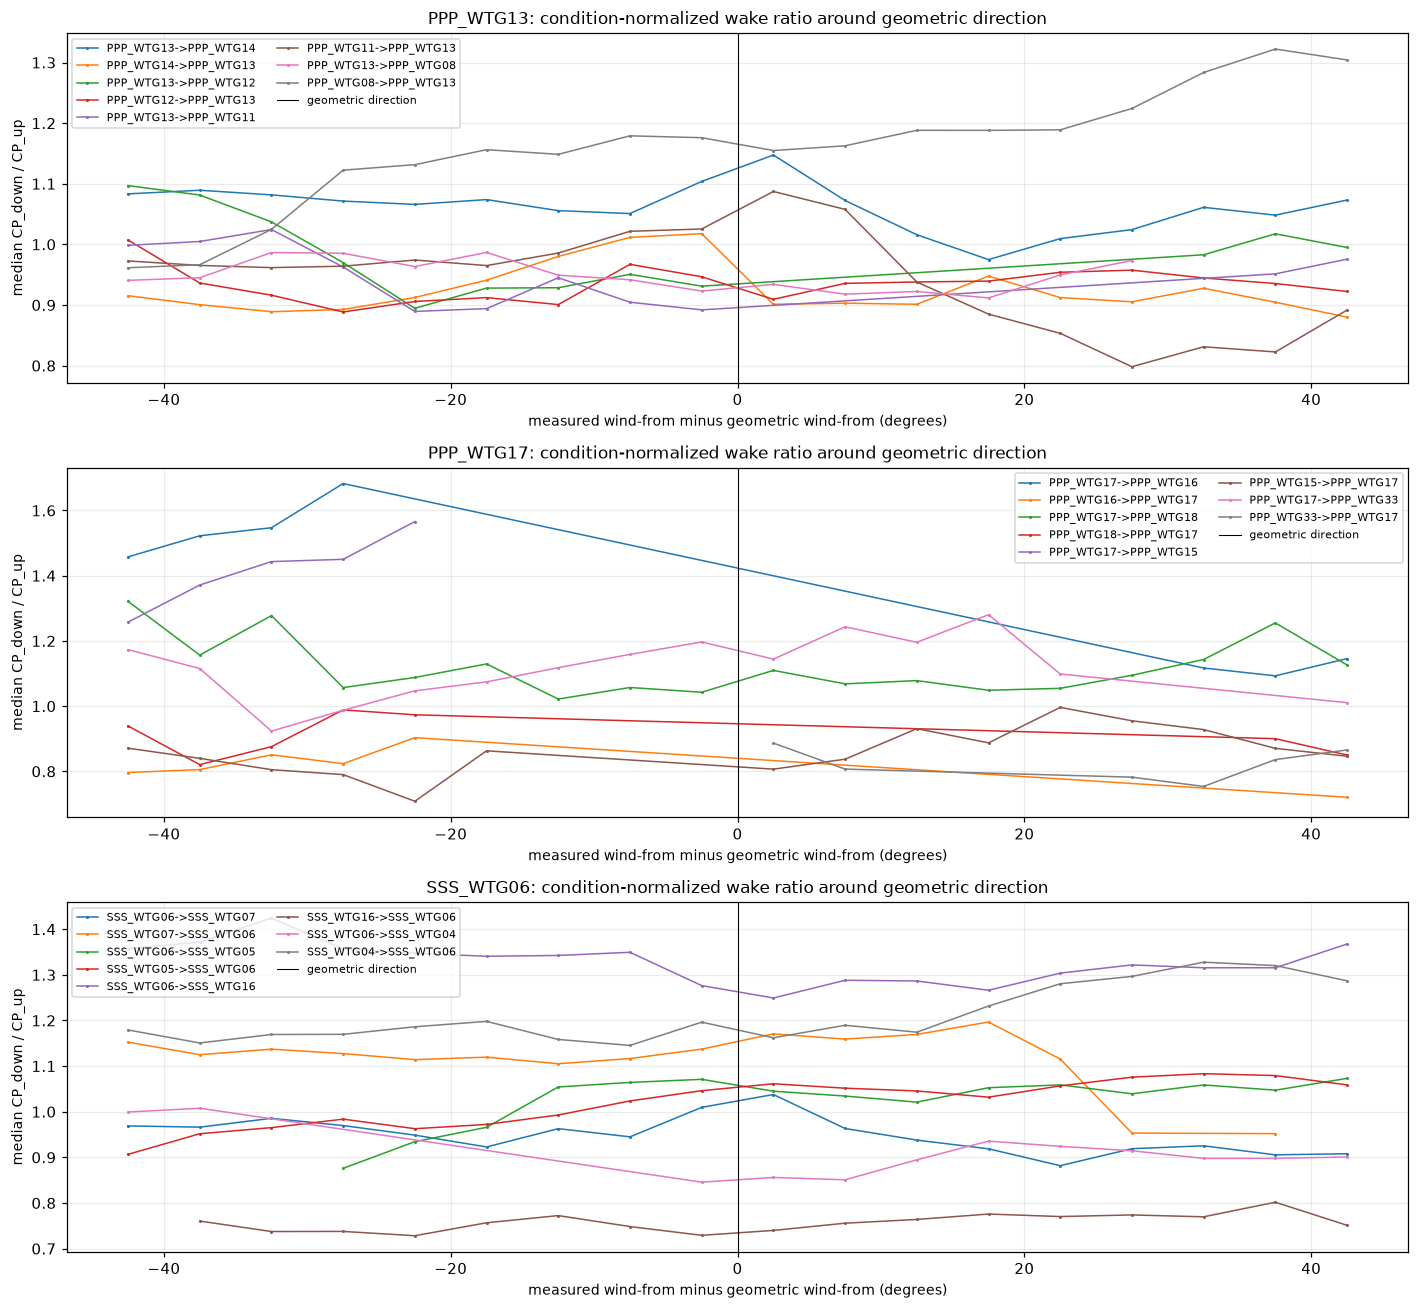

Full-period wake-direction audit:


,target,upstream,downstream,distance_m,geometric_wind_from_deg,n_filtered,n_curve_bins,observed_wind_from_deg,offset_deg,trough_ratio,median_ratio_near_window,trough_prominence
0,PPP_WTG13,PPP_WTG13,PPP_WTG14,317.933,199.820,11170,18,217.320,17.5,0.975,1.069,0.094
1,PPP_WTG13,PPP_WTG14,PPP_WTG13,317.933,19.820,11170,18,62.320,42.5,0.880,0.909,0.029
2,PPP_WTG13,PPP_WTG13,PPP_WTG12,528.384,26.444,10248,12,3.944,-22.5,0.895,0.976,0.082
3,PPP_WTG13,PPP_WTG12,PPP_WTG13,528.384,206.444,10248,18,178.944,-27.5,0.888,0.936,0.047
4,PPP_WTG13,PPP_WTG13,PPP_WTG11,877.132,24.303,9408,11,1.803,-22.5,0.889,0.951,0.062
5,PPP_WTG13,PPP_WTG11,PPP_WTG13,877.132,204.303,9408,18,231.803,27.5,0.798,0.965,0.166
6,PPP_WTG13,PPP_WTG13,PPP_WTG08,1224.064,145.017,8781,15,162.517,17.5,0.912,0.945,0.033
7,PPP_WTG13,PPP_WTG08,PPP_WTG13,1224.064,325.017,8781,18,282.517,-42.5,0.961,1.169,0.208
8,PPP_WTG17,PPP_WTG17,PPP_WTG16,333.673,34.919,11331,7,72.419,37.5,1.093,1.458,0.365
9,PPP_WTG17,PPP_WTG16,PPP_WTG17,333.673,214.919,11331,6,257.419,42.5,0.721,0.815,0.094


Quarterly wake-direction audit:


,target,upstream,downstream,quarter,geometric_wind_from_deg,n_filtered,n_curve_bins,observed_wind_from_deg,offset_deg,trough_ratio,median_ratio_near_window,trough_prominence
0,PPP_WTG13,PPP_WTG13,PPP_WTG14,2023Q3,199.820,1568,2,167.320,-32.5,1.096,1.097,0.001
1,PPP_WTG13,PPP_WTG13,PPP_WTG14,2023Q4,199.820,1123,4,242.320,42.5,0.991,1.002,0.011
2,PPP_WTG13,PPP_WTG13,PPP_WTG14,2024Q1,199.820,1287,6,222.320,22.5,1.005,1.052,0.047
3,PPP_WTG13,PPP_WTG13,PPP_WTG14,2024Q2,199.820,1550,3,227.320,27.5,1.053,1.061,0.008
4,PPP_WTG13,PPP_WTG13,PPP_WTG14,2024Q4,199.820,1450,2,157.320,-42.5,1.074,1.075,0.002
...,...,...,...,...,...,...,...,...,...,...,...,...
119,SSS_WTG06,SSS_WTG06,SSS_WTG04,2023Q4,48.742,1311,4,76.242,27.5,0.952,0.994,0.041
120,SSS_WTG06,SSS_WTG06,SSS_WTG04,2024Q1,48.742,1087,5,81.242,32.5,0.895,0.933,0.038
121,SSS_WTG06,SSS_WTG06,SSS_WTG04,2024Q4,48.742,1355,7,91.242,42.5,0.815,0.877,0.062
122,SSS_WTG06,SSS_WTG04,SSS_WTG06,2023Q1,228.742,1218,3,241.242,12.5,1.172,1.227,0.055


In [11]:
# Wake trough versus layout direction; full-period and quarterly summaries.
WAKE_DIRECTION_COL = 'WindDir'
WAKE_SPEED_RANGE = (5.0, 9.0)
WAKE_PITCH_LIMIT_DEG = 0.5
WAKE_MAX_REL_DEG = 45.0
WAKE_BIN_WIDTH_DEG = 5.0
WAKE_MIN_BIN_COUNT = 20
N_CLOSE_PAIRS = 4

def _bearing_from_to(source, target):
    # Clockwise bearing from north; x is east/west and y is north/south.
    dx = float(layout.loc[target, 'x'] - layout.loc[source, 'x'])
    dy = float(layout.loc[target, 'y'] - layout.loc[source, 'y'])
    return float(np.mod(np.degrees(np.arctan2(dx, dy)), 360.0))

def _wake_curve(frame, expected_wind_from):
    required = ['power_up', 'power_down', 'speed_up', 'speed_down', 'pitch_up', 'pitch_down', 'direction']
    z = frame[required].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    z = z[(z['power_up'] > 0) & (z['power_down'] > 0)]
    z = z[z['speed_up'].between(*WAKE_SPEED_RANGE) & z['speed_down'].between(*WAKE_SPEED_RANGE)]
    z = z[(z['pitch_up'] <= WAKE_PITCH_LIMIT_DEG) & (z['pitch_down'] <= WAKE_PITCH_LIMIT_DEG)]
    if len(z) < WAKE_MIN_BIN_COUNT:
        return None, pd.Series(dtype=float), pd.Series(dtype=int)
    cp_up = z['power_up'] / np.maximum(z['speed_up'], 0.1) ** 3
    cp_down = z['power_down'] / np.maximum(z['speed_down'], 0.1) ** 3
    ratio = cp_down / cp_up
    relative = wrap_180(np.mod(z['direction'].to_numpy(dtype=float), 360.0) - expected_wind_from)
    valid = np.isfinite(ratio.to_numpy(dtype=float)) & np.isfinite(relative) & (np.abs(relative) <= WAKE_MAX_REL_DEG)
    if not np.any(valid):
        return None, pd.Series(dtype=float), pd.Series(dtype=int)
    rel_bin = np.floor((relative[valid] + WAKE_MAX_REL_DEG) / WAKE_BIN_WIDTH_DEG) * WAKE_BIN_WIDTH_DEG - (WAKE_MAX_REL_DEG - WAKE_BIN_WIDTH_DEG / 2.0)
    grouped = pd.DataFrame({'bin': rel_bin, 'ratio': ratio.to_numpy(dtype=float)[valid]}).groupby('bin', observed=True)['ratio']
    curve = grouped.median().sort_index()
    counts = grouped.size().reindex(curve.index)
    curve = curve[counts >= WAKE_MIN_BIN_COUNT]
    counts = counts.reindex(curve.index)
    if curve.empty:
        return None, curve, counts
    trough_rel = float(curve.idxmin())
    trough_ratio = float(curve.min())
    summary = {
        'n_filtered': int(len(z)),
        'n_curve_bins': int(len(curve)),
        'observed_wind_from_deg': float(np.mod(expected_wind_from + trough_rel, 360.0)),
        'offset_deg': float(trough_rel),
        'trough_ratio': trough_ratio,
        'median_ratio_near_window': float(curve.median()),
        'trough_prominence': float(curve.median() - trough_ratio),
    }
    return summary, curve, counts

wake_rows = []
wake_quarter_rows = []
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(13, 4.0 * len(TARGETS)), squeeze=False)
for row, target in enumerate(TARGETS):
    if target not in layout.index:
        continue
    candidates = candidate_neighbours(target, layout, fleet_cfg).head(N_CLOSE_PAIRS)
    ax = axes[row, 0]
    for neighbour, candidate in candidates.iterrows():
        if neighbour not in binned or target not in binned:
            continue
        for upstream, downstream in ((target, neighbour), (neighbour, target)):
            expected = _bearing_from_to(downstream, upstream)
            pair = pd.concat({
                'power_up': binned[upstream]['Power'],
                'power_down': binned[downstream]['Power'],
                'speed_up': binned[upstream]['WindSpeed'],
                'speed_down': binned[downstream]['WindSpeed'],
                'pitch_up': binned[upstream]['PitchAngle'],
                'pitch_down': binned[downstream]['PitchAngle'],
                'direction': binned[upstream][WAKE_DIRECTION_COL],
            }, axis=1, sort=False).dropna()
            summary, curve, counts = _wake_curve(pair, expected)
            if summary is None:
                continue
            row_out = {
                'target': target,
                'upstream': upstream,
                'downstream': downstream,
                'distance_m': float(candidate['distance']),
                'geometric_wind_from_deg': expected,
                **summary,
            }
            wake_rows.append(row_out)
            ax.plot(curve.index, curve.values, marker='.', ms=2, lw=1.0, label=f'{upstream}->{downstream}')

            quarter = pair.index.to_period('Q').astype(str)
            for q, qidx in pair.groupby(quarter).groups.items():
                q_summary, _, _ = _wake_curve(pair.loc[qidx], expected)
                if q_summary is not None:
                    wake_quarter_rows.append({
                        'target': target,
                        'upstream': upstream,
                        'downstream': downstream,
                        'quarter': q,
                        'geometric_wind_from_deg': expected,
                        **q_summary,
                    })
    ax.axvline(0, color='k', lw=0.7, label='geometric direction')
    ax.set_title(f'{target}: condition-normalized wake ratio around geometric direction')
    ax.set_xlabel('measured wind-from minus geometric wind-from (degrees)')
    ax.set_ylabel('median CP_down / CP_up')
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()
print('Full-period wake-direction audit:')
display(pd.DataFrame(wake_rows).round(3))
print('Quarterly wake-direction audit:')
display(pd.DataFrame(wake_quarter_rows).round(3))

## Soft pair-quality weighting of frozen state levels

This ablation keeps the detected boundaries fixed. It does not delete days. A day with larger pair spread contributes less to its state level through a continuous weight, while the final comparison reports the change in state levels and boundary jumps.

In [12]:
from fleet_context import circular_mean_deg, circular_median_deg
from yaw_relative_state import label_free_boundaries, clusters_from_boundaries

PAIR_SPREAD_SCALE_DEG = 2.5
soft_state_rows = []
soft_boundary_rows = []
soft_daily_tables = {}

def weighted_circular_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    good = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(good):
        return np.nan
    values, weights = values[good], weights[good]
    origin = circular_mean_deg(values)
    local = wrap_180(values - origin)
    order = np.argsort(local)
    cumulative = np.cumsum(weights[order])
    local_median = local[order[np.searchsorted(cumulative, 0.5 * cumulative[-1])]]
    return float(wrap_180(origin + local_median))

for tid in TARGETS:
    daily, diag, pair_daily = bundles.get(tid, (pd.DataFrame(), pd.DataFrame(), pd.DataFrame()))
    if daily.empty or pair_daily.empty:
        continue
    boundaries = frozen_state_tables.get(tid, pd.DataFrame())
    if boundaries.empty:
        weights = diag.reindex(pair_daily.columns)['reliability_weight'].to_numpy(dtype=float)
        boundaries = label_free_boundaries(daily, pair_daily, weights, rel_cfg)
        frozen_state_tables[tid] = boundaries.copy()
    state_id = clusters_from_boundaries(daily.index, boundaries)

    values = pair_daily.reindex(daily.index).to_numpy(dtype=float)
    has_pair = np.isfinite(values).any(axis=1)
    pair_median = np.full(len(values), np.nan)
    pair_median[has_pair] = np.nanmedian(values[has_pair], axis=1)
    deviations = np.abs(wrap_180(values - pair_median[:, None]))
    pair_spread = np.full(len(values), np.nan)
    pair_spread[has_pair] = np.nanmedian(deviations[has_pair], axis=1)
    n_pairs = np.isfinite(values).sum(axis=1)
    pair_fraction = n_pairs / max(values.shape[1], 1)
    q_spread = 1.0 / (1.0 + (pair_spread / PAIR_SPREAD_SCALE_DEG) ** 2)
    q_day = np.where(has_pair & np.isfinite(pair_spread), q_spread * pair_fraction, 0.0)
    quality = pd.DataFrame({
        'state': state_id.to_numpy(dtype=int),
        'r': daily['relative_heading_smooth'].to_numpy(dtype=float),
        'pair_spread_deg': pair_spread,
        'n_usable_pairs': n_pairs,
        'q_day': q_day,
    }, index=daily.index)
    soft_daily_tables[tid] = quality
    levels = {}
    for state, part in quality.groupby('state', observed=True):
        valid = part['r'].notna()
        level_all = circular_median_deg(part.loc[valid, 'r'])
        level_soft = weighted_circular_median(part.loc[valid, 'r'], part.loc[valid, 'q_day'])
        levels[int(state)] = {'all': level_all, 'soft': level_soft}
        soft_state_rows.append({
            'turbine': tid,
            'state': int(state),
            'n_days': int(valid.sum()),
            'mean_q_day': part['q_day'].mean(),
            'level_all_deg': level_all,
            'level_soft_deg': level_soft,
            'soft_minus_all_deg': wrap_180(level_soft - level_all),
        })

    accepted_dates = pd.DatetimeIndex(boundaries.index[boundaries['accepted'].fillna(False)])
    for date in accepted_dates:
        left_state = state_id.get(date - pd.Timedelta(days=1), np.nan)
        right_state = state_id.get(date, np.nan)
        if not np.isfinite(left_state) or not np.isfinite(right_state) or left_state == right_state:
            continue
        left, right = levels.get(int(left_state), {}), levels.get(int(right_state), {})
        soft_boundary_rows.append({
            'turbine': tid,
            'boundary': date,
            'jump_all_deg': wrap_180(right.get('all', np.nan) - left.get('all', np.nan)),
            'jump_soft_deg': wrap_180(right.get('soft', np.nan) - left.get('soft', np.nan)),
            'jump_change_deg': wrap_180((right.get('soft', np.nan) - left.get('soft', np.nan)) - (right.get('all', np.nan) - left.get('all', np.nan))),
        })

print(f'Soft weighting: q_spread = 1 / (1 + (pair_spread / {PAIR_SPREAD_SCALE_DEG:.1f})^2); boundaries unchanged')
print('State levels: all days versus soft pair-quality weighted')
display(pd.DataFrame(soft_state_rows).round(3))
print('Frozen-boundary jumps: all days versus soft pair-quality weighted')
display(pd.DataFrame(soft_boundary_rows).round(3))

Soft weighting: q_spread = 1 / (1 + (pair_spread / 2.5)^2); boundaries unchanged
State levels: all days versus soft pair-quality weighted


,turbine,state,n_days,mean_q_day,level_all_deg,level_soft_deg,soft_minus_all_deg
0,PPP_WTG13,0,49,0.345,3.970,4.111,0.141
1,PPP_WTG13,1,158,0.459,1.707,2.019,0.312
2,PPP_WTG13,2,227,0.599,-1.292,-1.061,0.231
3,PPP_WTG13,3,297,0.679,-0.596,-0.743,-0.147
4,PPP_WTG17,0,175,0.609,4.641,4.682,0.040
5,PPP_WTG17,1,91,0.637,4.150,4.010,-0.140
6,PPP_WTG17,2,21,0.582,7.340,7.340,0.000
7,PPP_WTG17,3,78,0.567,5.780,5.663,-0.118
8,PPP_WTG17,4,360,0.602,-3.429,-3.429,0.000
9,SSS_WTG06,0,81,0.497,0.636,0.587,-0.049


Frozen-boundary jumps: all days versus soft pair-quality weighted


C:\Users\HJL\AppData\Local\Temp\ipykernel_27016\2752935398.py:88: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(pd.DataFrame(soft_boundary_rows).round(3))


,turbine,boundary,jump_all_deg,jump_soft_deg,jump_change_deg
0,PPP_WTG13,2023-02-19,-2.262,-2.092,0.170
1,PPP_WTG13,2023-07-27,-3.000,-3.080,-0.080
2,PPP_WTG13,2024-03-10,0.696,0.318,-0.378
3,PPP_WTG17,2023-06-25,-0.491,-0.672,-0.180
4,PPP_WTG17,2023-09-24,3.190,3.330,0.140
5,PPP_WTG17,2023-10-15,-1.560,-1.678,-0.118
6,PPP_WTG17,2024-01-07,-9.210,-9.092,0.118
7,SSS_WTG06,2023-05-07,6.793,6.904,0.111
8,SSS_WTG06,2023-05-28,0.148,-0.486,-0.634
9,SSS_WTG06,2023-09-24,-7.424,-7.069,0.355
